In [1]:
# from gensim.models import Word2Vec
# import gensim
from nltk.tokenize import sent_tokenize, word_tokenize
import warnings
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import nltk
import torch
import random
import json
import random
import torch
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
with open("./data/train_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [4]:
words_list = [sentence['tokens'] for sentence in data]
labels_list = [sentence['ner_tags'] for sentence in data]
print(words_list)
print(labels_list)

[['τὴν', 'σωματικὴν', 'ἄσκησιν', 'συμβάλλεσθαι', 'πρὸς', 'ἀρετῆς', 'ἀνάληψιν'], ['Μυρωνιανὸς', 'δὲ', 'ἐν', 'Ὁμοίοις', '(', 'FHG', 'iv', '454', ')', 'φησὶν', 'ὅτι', 'Κούρητα', 'αὐτὸν', 'ἐκάλουν', 'Κρῆτες', '·'], ['Τούτων', 'τε', 'ὦν', 'εἵνεκεν', 'οἱ', 'Λακεδαιμόνιοι', 'τὴν', 'συμμαχίην', 'ἐδέξαντο', ',', 'καὶ', 'ὅτι', 'ἐκ', 'πάντων', 'σφέας', 'προκρίνας', 'Ἑλλήνων', 'αἱρέετο', 'φίλους', '.'], ['Ἔστι', 'δὲ', 'ἀπὸ', 'τῆς', 'λίμνης', 'τῆς', 'Μαιήτιδος', 'ἐπὶ', 'Φᾶσιν', 'ποταμὸν', 'καὶ', 'ἐς', 'Κόλχους', 'τριήκοντα', 'ἡμερέων', 'εὐζώνῳ', 'ὁδός', ',', 'ἐκ', 'δὲ', 'τῆς', 'Κολχίδος', 'οὐ', 'πολλὸν', 'ὑπερβῆναι', 'ἐς', 'τὴν', 'Μηδικήν', ',', "ἀλλ'", 'ἓν', 'τὸ', 'διὰ', 'μέσου', 'ἔθνος', 'αὐτῶν', 'ἐστι', ',', 'Σάσπειρες', ',', 'τοῦτο', 'δὲ', 'παραμειβομένοισι', 'εἶναι', 'ἐν', 'τῇ', 'Μηδικῇ', '.'], ['»', 'Ἅρπαγε', ',', 'τέῳ', 'δὴ', 'μόρῳ', 'τὸν', 'παῖδα', 'κατεχρήσαο', 'τόν', 'τοι', 'παρέδωκα', 'ἐκ', 'θυγατρὸς', 'γεγονότα', 'τῆς', 'ἐμῆς', ';', '«', 'Ὁ', 'δὲ', 'Ἅρπαγος', ',', 'ὡς', 'εἶδε', 'τὸν', '

# Fast Text

each word have an unique embedding
OOV words have their own embedding through summing up N-gram

https://amitness.com/posts/fasttext-embeddings

In [13]:
!pip install fasttext
import fasttext

In [11]:
model_path = "./models/grc_fasttext_skipgram_nn2_xn10_dim150.bin"
ft_model = fasttext.load_model(model_path)

ModuleNotFoundError: No module named 'fasttext'

In [ ]:
words = sorted(set(word for sentence in words_list for word in sentence))
print(words)
embeddings = np.array([ft_model.get_word_vector(word) for word in words])

In [ ]:
embedding_dict = {word: embeddings[i].tolist() for i, word in enumerate(words)}

with open("./data/fasttext_emb.json", "w", encoding="utf-8") as f:
    json.dump(embedding_dict, f, ensure_ascii=False)

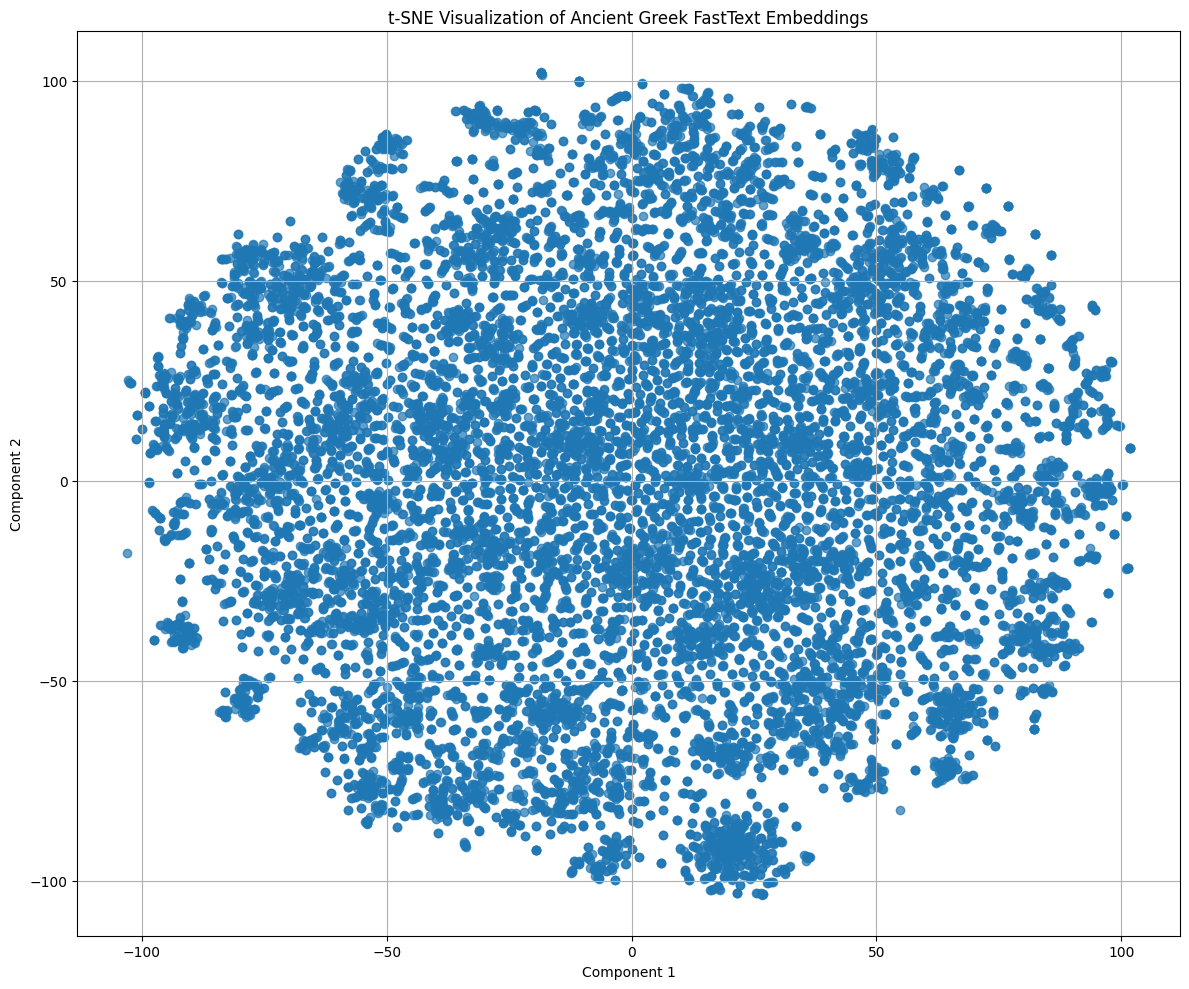

In [ ]:
# tsne = TSNE(n_components=2, perplexity=5, random_state=42)
# embeddings_2d = tsne.fit_transform(embeddings)

# plt.figure(figsize=(12, 10))
# plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7)

# plt.title("t-SNE Visualization of Ancient Greek FastText Embeddings")
# plt.xlabel("Component 1")
# plt.ylabel("Component 2")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# GMM Clustering

* num_cluster is a hyperparametre
* T rescaling temperature is a hyper parametre

In [30]:
# Load the JSON file
with open("./data/fasttext_emb.json", "r", encoding="utf-8") as f:
    embedding_dict = json.load(f)

# Extract words and embeddings
words = list(embedding_dict.keys())
embeddings = [embedding_dict[word] for word in words]

print(words)
print(embeddings)

[' ', '  ', "'", '(', ')', ',', '.', '1', '10', '105', '106', '11', '115', '115a', '12', '13', '130', '135', '137', '138', '14', '142cd', '144', '15', '153', '16', '162', '163', '169', '16—20', '17', '170', '174a', '18', '180c', '182', '19', '191', '193', '199', '1—12', '1—4', '2', '20', '201', '207', '21', '218', '21a', '22', '221', '228', '23', '23e', '241', '244', '25', '257', '26', '264', '265', '27', '271', '273', '28', '299', '3', '30', '300', '31', '316', '317', '32', '328', '334', '338', '338a', '343', '343a', '345d', '347', '35', '36', '360', '362', '37', '377', '379', '38', '382', '39', '392', '397', '4', '40', '405a', '412—17', '42', '429', '43', '44', '453', '454', '46', '460', '461', '49', '490', '492', '4a', '4b', '5', '501', '502', '508', '51', '521', '52a', '54', '541', '542', '546—7', '55', '557—8', '559', '566', '577', '578', '581', '583', '59', '594', '595', '596', '59c', '6', '608', '609', '61', '615', '616', '617', '636', '637', '65', '66', '672', '67a', '68', '69'

KeyboardInterrupt: 

In [14]:
from sklearn.mixture import GaussianMixture
num_clusters = 5
gmm = GaussianMixture(n_components=num_clusters, covariance_type='full', random_state=42)
gmm.fit(embeddings)

GaussianMixture(n_components=5, random_state=42)

In [15]:
labels = gmm.predict(embeddings)
probs = gmm.predict_proba(embeddings)
print(len(probs))

17765


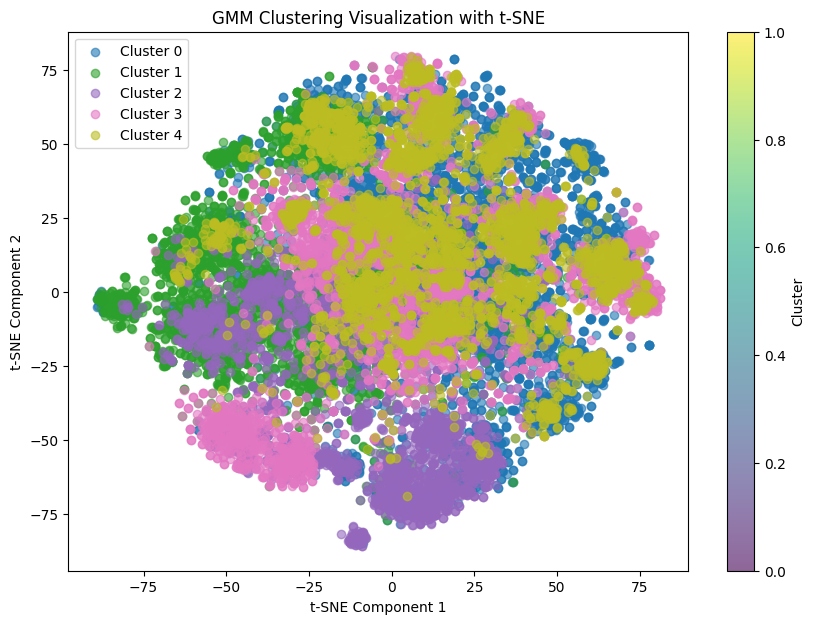

In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# import numpy as np
# import matplotlib

# colors = matplotlib.colormaps['tab10']

# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# X_tsne = tsne.fit_transform(embeddings)


# plt.figure(figsize=(10, 7))
# for cluster in range(num_clusters):
#     cluster_points = X_tsne[labels == cluster]
#     plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
#                 color=colors(cluster / num_clusters), label=f"Cluster {cluster}", alpha=0.6)

# plt.colorbar(label="Cluster")
# plt.title("GMM Clustering Visualization with t-SNE")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.legend()
# plt.show()

In [16]:
def temperature_scaled_probs(log_probs, T):
    """
    Applies temperature scaling to log-probabilities and returns rescaled probabilities.
    """
    scaled_logits = log_probs / T
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))  # for numerical stability
    return exp_logits / np.sum(exp_logits)

In [17]:
def compute_lpg(log_probs):
    """
    Computes the Log-Probability Gap (LPG) score for each sample.
    """
    n_samples, K = log_probs.shape

    # Get predicted labels (argmax of log_probs)
    y_hat = np.argmax(log_probs, axis=1)

    # Compute MINGAP for each sample
    min_gaps = []
    for i in range(n_samples):
        true_log_prob = log_probs[i, y_hat[i]]
        other_log_probs = np.delete(log_probs[i], y_hat[i])
        min_gap = np.min(true_log_prob - other_log_probs)
        min_gaps.append(min_gap)

    min_gaps = np.array(min_gaps)

    # Normalize to get LPG scores
    max_gap = np.max(min_gaps)
    lpg_scores = min_gaps / max_gap if max_gap > 0 else np.zeros_like(min_gaps)

    return lpg_scores

In [18]:
#scale the probability
scaled_probs = temperature_scaled_probs(np.log(probs), T=20)

#compute LPG scores
lpg_scores = compute_lpg(probs)
scaled_lpg_scores = compute_lpg(scaled_probs)

print(scaled_lpg_scores[0:10])

<ipython-input-18-4246780997>:2: RuntimeWarning: divide by zero encountered in log
  scaled_probs = temperature_scaled_probs(np.log(probs), T=20)


[0.97040664 0.54891567 0.99999989 0.89586155 0.86239903 0.92093918
 0.96838945 0.89747734 0.88386565 0.94128437]


In [19]:
print(f"prob before scaling: \n {probs}\n")
print(f"prob after scaling: \n {scaled_probs}\n")


print(f"conf score before scaling: \n {lpg_scores[0:10]}\n")
print(f"conf score after scaling: \n {scaled_lpg_scores[0:10]}\n")

prob before scaling: 
 [[1.00000000e+000 1.17747118e-032 3.32492459e-052 4.59865204e-034
  2.65389843e-031]
 [9.99999878e-001 3.52406770e-019 1.21661939e-007 2.94239357e-037
  9.24851081e-030]
 [1.00000000e+000 0.00000000e+000 0.00000000e+000 4.71318288e-140
  4.55757021e-160]
 ...
 [1.28244070e-028 1.29660385e-021 1.00000000e+000 3.77910867e-059
  5.44869031e-060]
 [3.40728811e-012 3.18968819e-009 9.99999997e-001 1.11469958e-014
  1.41770299e-011]
 [5.20429386e-029 1.68429640e-027 1.00000000e+000 2.20116415e-064
  2.53915448e-065]]

prob after scaling: 
 [[3.48161643e-05 8.81715424e-07 9.28688384e-08 7.49743054e-07
  1.03032714e-06]
 [3.48161641e-05 4.16038130e-06 1.57050260e-05 5.19058087e-07
  1.23050821e-06]
 [3.48161643e-05 0.00000000e+00 0.00000000e+00 3.76224123e-12
  3.75593088e-13]
 ...
 [1.40340425e-06 3.14355663e-06 3.48161643e-05 4.17494148e-08
  3.78961883e-08]
 [9.29825316e-06 1.30908647e-05 3.48161643e-05 6.98455619e-06
  9.98527859e-06]
 [1.34152575e-06 1.59625345e-06 3

In [ ]:
word_to_probs = dict(zip(words, scaled_lpg_scores))

In [ ]:
with open('./data/word_to_probs.json', 'w', encoding='utf-8') as f:
    json.dump(word_to_probs, f, ensure_ascii=False, indent=4)

## TODO: Mahalanobis Score

1.   Set a threshold for the score (95th percentile)
2.   Flag the words goes above the threshold
3.   Compute Mahlanobis dist of flag words to each of the cluster
4.   Assign the word to the cluster with the lowest distance


In [ ]:
#k: cluster index, x: the datapoint of interest
k=0
mean_k = gmm.means_[k]
cov_k = gmm.covariances_[k]
cov_inv_k = np.linalg.inv(cov_k)

In [ ]:
from scipy.spatial.distance import mahalanobis
x=test_embeddings[5]
md=mahalanobis(x, mean_k, cov_inv_k)
print(md)

7.863401536383834


# extract prediction and probability

In [7]:
df = pd.read_csv('./data/base_result.csv')

label_dict = {}

for _, row in df.iterrows():
    word = row["word"]
    label = row["pseudoLabel"]
    log_prob = row.get(label)

    if pd.notna(log_prob):
        prob = np.exp(log_prob)

    label_dict[word] = (label, prob)

print(label_dict)

{'τὴν': ('O', np.float64(0.9859360865439137)), 'σωματικὴν': ('O', np.float64(0.9999998063873693)), 'ἄσκησιν': ('O', np.float64(0.999999091165777)), 'συμβάλλεσθαι': ('O', np.float64(0.9999975415208362)), 'πρὸς': ('O', np.float64(1.0)), 'ἀρετῆς': ('O', np.float64(0.9999984951481292)), 'ἀνάληψιν': ('O', np.float64(0.9999641651356604)), 'Μυρωνιανὸς': ('PERSON', np.float64(0.9999242341327902)), 'δὲ': ('O', np.float64(1.0)), 'ἐν': ('O', np.float64(0.9999998063873693)), 'Ὁμοίοις': ('O', np.float64(0.9999036136757582)), '(': ('O', np.float64(1.0)), 'FHG': ('O', np.float64(0.9999978991308366)), 'iv': ('O', np.float64(0.6778611064392233)), '454': ('O', np.float64(0.9998762071859499)), ')': ('O', np.float64(0.9999995679801056)), 'φησὶν': ('O', np.float64(0.9999831180163555)), 'ὅτι': ('O', np.float64(0.9999998063873693)), 'Κούρητα': ('LOC', np.float64(0.9986633891153963)), 'αὐτὸν': ('O', np.float64(0.9999998063873693)), 'ἐκάλουν': ('O', np.float64(0.9999978991308366)), 'Κρῆτες': ('LOC', np.float64

In [23]:
combined_dict = {}

for word, (label, label_confidence) in label_dict.items():
    gmm_confidence = word_to_probs.get(word)
    combined = label_confidence * gmm_confidence
    combined_dict[word] = {
        "label": label,
        "combined_confidence": float(combined)
        }


In [25]:
for word, vals in list(combined_dict.items())[:3]:
    print(f"{word}: {vals}")

τὴν: {'label': 'O', 'combined_confidence': 0.7036365877655084}
σωματικὴν: {'label': 'O', 'combined_confidence': 0.77848181922127}
ἄσκησιν: {'label': 'O', 'combined_confidence': 0.7984799505870127}


In [26]:
for word, vals in list(combined_dict.items())[:10]:
    print(vals["combined_confidence"])

0.7036365877655084
0.77848181922127
0.7984799505870127
0.8469418685131685
0.22448426314679365
0.48043779280417254
0.7059725785641368
0.6994871013469386
0.3860683514306377
0.48890886222922975


In [27]:
words_output = []
labels_output = []
confidences_output = []

for sentence in words_list:
    sentence_words = []
    sentence_labels = []
    sentence_confs = []

    for word in sentence:
        if word in combined_dict:
            vals = combined_dict[word]
            sentence_words.append(word)
            sentence_labels.append(vals["label"])
            sentence_confs.append(round(float(vals["combined_confidence"]), 4))

    words_output.append(sentence_words)
    labels_output.append(sentence_labels)
    confidences_output.append(sentence_confs)

# Example output for first sentence
print("Words:", words_output[0])
print("Labels:", labels_output[0])
print("Confidences:", confidences_output[0])


Words: ['τὴν', 'σωματικὴν', 'ἄσκησιν', 'συμβάλλεσθαι', 'πρὸς', 'ἀρετῆς', 'ἀνάληψιν']
Labels: ['O', 'O', 'O', 'O', 'O', 'O', 'O']
Confidences: [0.7036, 0.7785, 0.7985, 0.8469, 0.2245, 0.4804, 0.706]


In [29]:
data = []

for tokens, labels, confs in zip(words_output, labels_output, confidences_output):
    data.append({
        "tokens": tokens,
        "labels": labels,
        "confidences": confs
    })

with open("./data/combined_confidence.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print("Saved to combined_confidence.json")


Saved to combined_confidence.json
